In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q tensorflow matplotlib scikit-learn

In [3]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [4]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# =========================
# CONFIGURATION
# =========================

DATA_DIR = "/content/drive/MyDrive/deepfake_project/data/processed_v2"
MODEL_OUTPUT_DIR = "/content/drive/MyDrive/deepfake_project/models/image_classifier_v2"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Training schedule
INITIAL_EPOCHS = 8
FINE_TUNE_EPOCHS = 5

# Learning rates
INITIAL_LR = 1e-3
FINE_TUNE_LR = 1e-5

# Fine-tuning: unfreeze top N layers
UNFREEZE_LAST_N_LAYERS = 30

os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("MODEL_OUTPUT_DIR:", MODEL_OUTPUT_DIR)

DATA_DIR: /content/drive/MyDrive/deepfake_project/data/processed_v2
MODEL_OUTPUT_DIR: /content/drive/MyDrive/deepfake_project/models/image_classifier_v2


In [6]:
required_paths = [
    os.path.join(DATA_DIR, "train"),
    os.path.join(DATA_DIR, "val"),
    os.path.join(DATA_DIR, "test"),
]

for path in required_paths:
    print(path, "->", os.path.exists(path))

print("\nTrain subfolders:", os.listdir(os.path.join(DATA_DIR, "train")))
print("Val subfolders:", os.listdir(os.path.join(DATA_DIR, "val")))
print("Test subfolders:", os.listdir(os.path.join(DATA_DIR, "test")))

/content/drive/MyDrive/deepfake_project/data/processed_v2/train -> True
/content/drive/MyDrive/deepfake_project/data/processed_v2/val -> True
/content/drive/MyDrive/deepfake_project/data/processed_v2/test -> True

Train subfolders: ['real', 'fake']
Val subfolders: ['real', 'fake']
Test subfolders: ['real', 'fake']


In [7]:
train_ds = keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 11184 files belonging to 2 classes.
Found 2400 files belonging to 2 classes.
Found 2416 files belonging to 2 classes.


In [8]:
class_names = train_ds.class_names
print("Class names:", class_names)

label_to_index = {name: i for i, name in enumerate(class_names)}
index_to_label = {i: name for i, name in enumerate(class_names)}

print("Label to index:", label_to_index)
print("Index to label:", index_to_label)

positive_class_name = index_to_label[1]
negative_class_name = index_to_label[0]

print("\nImportant:")
print(f"Sigmoid output near 1 means: {positive_class_name}")
print(f"Sigmoid output near 0 means: {negative_class_name}")

Class names: ['fake', 'real']
Label to index: {'fake': 0, 'real': 1}
Index to label: {0: 'fake', 1: 'real'}

Important:
Sigmoid output near 1 means: real
Sigmoid output near 0 means: fake


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

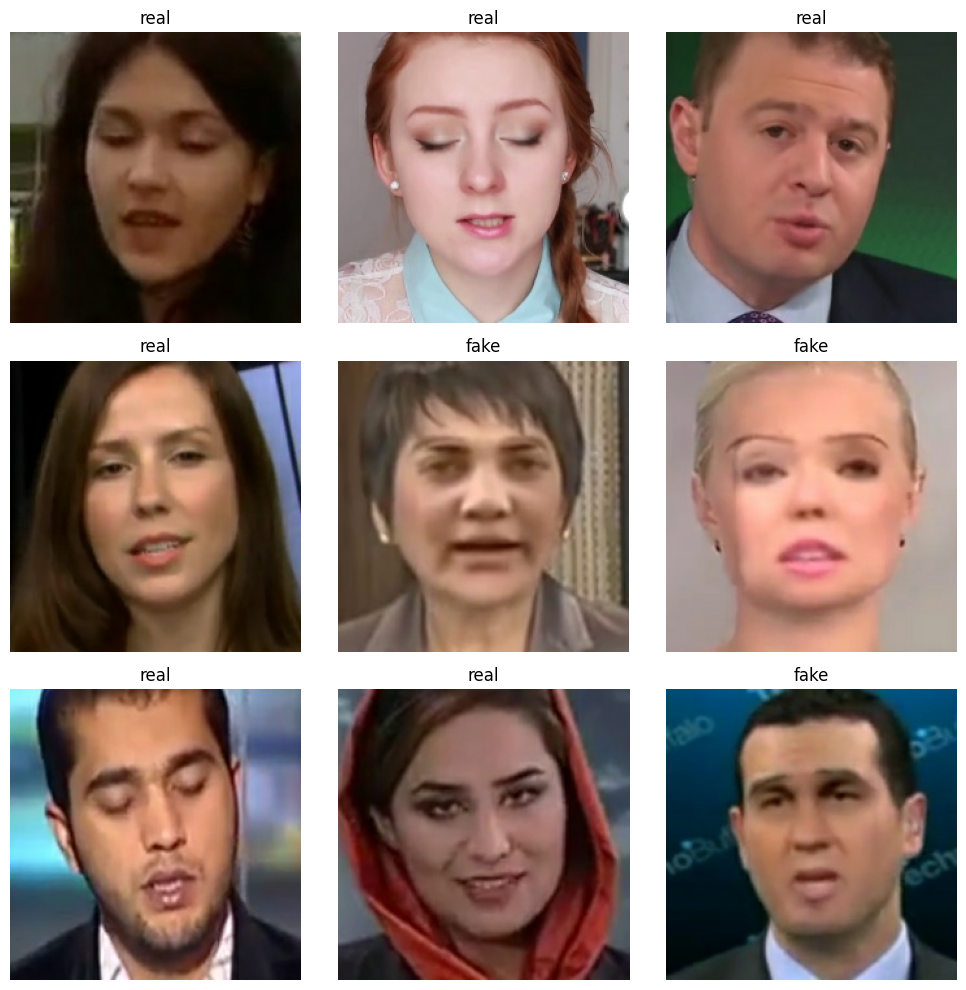

In [10]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_index = int(labels[i].numpy()[0])
        plt.title(index_to_label[label_index])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
def count_files_in_folder(folder_path):
    valid_exts = (".jpg", ".jpeg", ".png")
    return len([f for f in os.listdir(folder_path) if f.lower().endswith(valid_exts)])

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    split_path = os.path.join(DATA_DIR, split)
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            print(f"  {cls}: {count_files_in_folder(cls_path)}")


TRAIN
  fake: 5592
  real: 5592

VAL
  fake: 1200
  real: 1200

TEST
  fake: 1208
  real: 1208


In [12]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="data_augmentation")

In [13]:
base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)

base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=INITIAL_LR),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [14]:
stage1_checkpoint_path = os.path.join(MODEL_OUTPUT_DIR, "best_model_stage1_v2.keras")

callbacks_stage1 = [
    keras.callbacks.ModelCheckpoint(
        stage1_checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

In [15]:
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks_stage1
)

Epoch 1/8
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5349 - auc: 0.5449 - loss: 0.6990 - precision: 0.5288 - recall: 0.5201
Epoch 1: val_accuracy improved from None to 0.66167, saving model to /content/drive/MyDrive/deepfake_project/models/image_classifier_v2/best_model_stage1_v2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/deepfake_project/models/image_classifier_v2/best_model_stage1_v2.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 1492s 4s/step - accuracy: 0.5514 - auc: 0.5770 - loss: 0.6868 - precision: 0.5512 - recall: 0.5533 - val_accuracy: 0.6617 - val_auc: 0.7576 - val_loss: 0.6358 - val_precision: 0.6105 - val_recall: 0.8933 - learning_rate: 0.0010
Epoch 2/8
349/350 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.6057 - auc: 0.6513 - loss: 0.6566 - precision: 0.5983 - recall: 0.6092
Epoch 2: val_accuracy improved from 0.66167 to 0.70417, saving model to /content/drive/MyDrive/deepfake_project/models/image_classifier_v2/best_model_stage1_v2.keras

Epoch 2: fi

In [16]:
base_model.trainable = True

fine_tune_at = max(0, len(base_model.layers) - UNFREEZE_LAST_N_LAYERS)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

print(f"Fine-tuning last {UNFREEZE_LAST_N_LAYERS} layers of EfficientNetB0")
model.summary()

Fine-tuning last 30 layers of EfficientNetB0


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,497,441 (5.71 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

In [17]:
stage2_checkpoint_path = os.path.join(MODEL_OUTPUT_DIR, "best_model_finetuned_v2.keras")

callbacks_stage2 = [
    keras.callbacks.ModelCheckpoint(
        stage2_checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

In [18]:
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks_stage2
)

Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.6130 - auc: 0.6669 - loss: 0.6610 - precision: 0.6295 - recall: 0.5194
Epoch 1: val_accuracy improved from None to 0.75042, saving model to /content/drive/MyDrive/deepfake_project/models/image_classifier_v2/best_model_finetuned_v2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/deepfake_project/models/image_classifier_v2/best_model_finetuned_v2.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 72s 163ms/step - accuracy: 0.6324 - auc: 0.6916 - loss: 0.6393 - precision: 0.6484 - recall: 0.5787 - val_accuracy: 0.7504 - val_auc: 0.8333 - val_loss: 0.5242 - val_precision: 0.7048 - val_recall: 0.8617 - learning_rate: 1.0000e-05
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.6748 - auc: 0.7506 - loss: 0.5890 - precision: 0.6677 - recall: 0.6827
Epoch 2: val_accuracy improved from 0.75042 to 0.78208, saving model to /content/drive/MyDrive/deepfake_project/models/image_classifier_v2/best_model_finetuned_v2.k

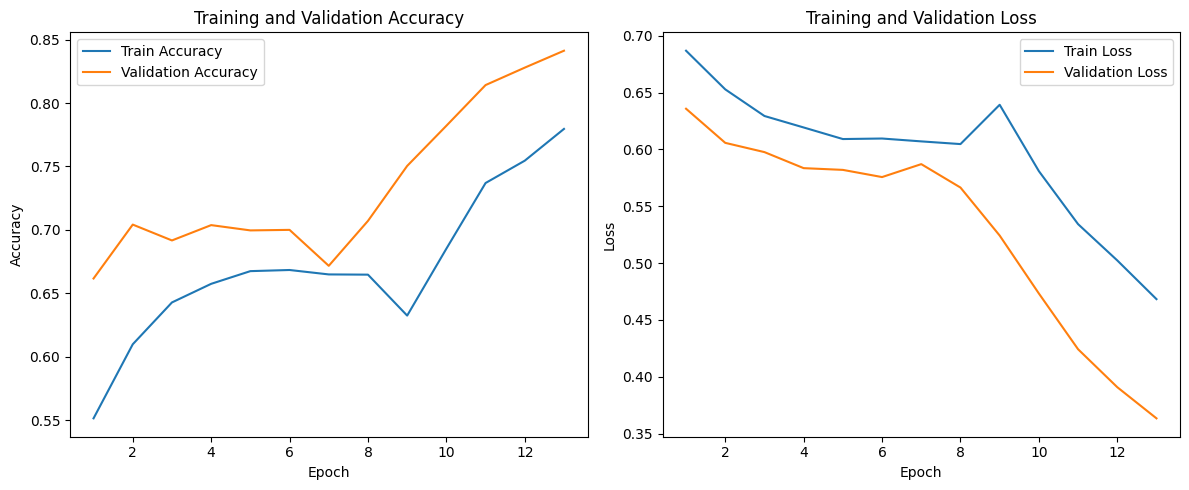

In [19]:
def plot_training_curves(history1, history2=None):
    acc = history1.history["accuracy"][:]
    val_acc = history1.history["val_accuracy"][:]
    loss = history1.history["loss"][:]
    val_loss = history1.history["val_loss"][:]

    if history2 is not None:
        acc += history2.history["accuracy"]
        val_acc += history2.history["val_accuracy"]
        loss += history2.history["loss"]
        val_loss += history2.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Train Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_curves(history_stage1, history_stage2)

In [20]:
test_results = model.evaluate(test_ds, verbose=1)

print("\nTest results:")
for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

76/76 ━━━━━━━━━━━━━━━━━━━━ 418s 5s/step - accuracy: 0.7972 - auc: 0.8912 - loss: 0.4200 - precision: 0.7867 - recall: 0.8154

Test results:
loss: 0.4200
compile_metrics: 0.7972


In [21]:
y_true = []
y_pred_prob_class1 = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0).flatten()
    y_pred_prob_class1.extend(preds.tolist())
    y_true.extend(labels.numpy().flatten().astype(int).tolist())

y_true = np.array(y_true).astype(int)
y_pred_prob_class1 = np.array(y_pred_prob_class1)

y_pred = (y_pred_prob_class1 >= 0.5).astype(int)

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:

              precision    recall  f1-score   support

        fake       0.81      0.78      0.79      1208
        real       0.79      0.82      0.80      1208

    accuracy                           0.80      2416
   macro avg       0.80      0.80      0.80      2416
weighted avg       0.80      0.80      0.80      2416



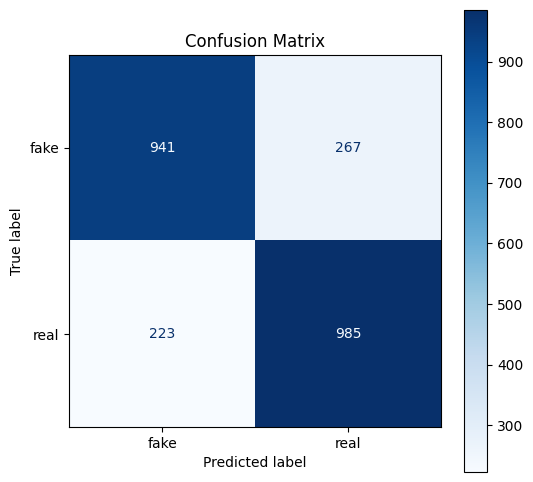

In [22]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [23]:
final_model_path = os.path.join(MODEL_OUTPUT_DIR, "saved_model_image_classifier_v2.keras")
model.save(final_model_path)

print("Saved final V2 model to:", final_model_path)

Saved final V2 model to: /content/drive/MyDrive/deepfake_project/models/image_classifier_v2/saved_model_image_classifier_v2.keras


In [24]:
label_mapping = {
    "class_names": class_names,
    "label_to_index": label_to_index,
    "index_to_label": {str(k): v for k, v in index_to_label.items()},
    "positive_class_name": positive_class_name,
    "negative_class_name": negative_class_name
}

labels_json_path = os.path.join(MODEL_OUTPUT_DIR, "labels_v2.json")

with open(labels_json_path, "w") as f:
    json.dump(label_mapping, f, indent=2)

print("Saved V2 labels to:", labels_json_path)

Saved V2 labels to: /content/drive/MyDrive/deepfake_project/models/image_classifier_v2/labels_v2.json


In [25]:
def predict_single_image(image_path, model, index_to_label, img_size=(224, 224)):
    img = keras.utils.load_img(image_path, target_size=img_size)
    x = keras.utils.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = keras.applications.efficientnet.preprocess_input(x)

    prob_class1 = float(model.predict(x, verbose=0)[0][0])
    prob_class0 = 1.0 - prob_class1

    if prob_class1 >= 0.5:
        pred_index = 1
        confidence = prob_class1
    else:
        pred_index = 0
        confidence = prob_class0

    pred_label = index_to_label[pred_index]

    print(f"Predicted label: {pred_label}")
    print(f"Confidence: {confidence:.4f}")
    print(f"Probability of {index_to_label[0]}: {prob_class0:.4f}")
    print(f"Probability of {index_to_label[1]}: {prob_class1:.4f}")

    return {
        "predicted_label": pred_label,
        "confidence": confidence,
        index_to_label[0]: prob_class0,
        index_to_label[1]: prob_class1
    }

In [27]:
sample_image_path = "/content/drive/MyDrive/deepfake_project/data/processed_v2/test/real/real_209_f00125.jpg"

if os.path.exists(sample_image_path):
    result = predict_single_image(sample_image_path, model, index_to_label, img_size=IMG_SIZE)
    print(result)
else:
    print("Update sample_image_path to a real V2 image file before testing.")

Predicted label: real
Confidence: 0.7410
Probability of fake: 0.2590
Probability of real: 0.7410
{'predicted_label': 'real', 'confidence': 0.7410474419593811, 'fake': 0.2589525580406189, 'real': 0.7410474419593811}
